# Geographic Distribution of Dataset Locations

This notebook visualizes the spatial distribution of locations in the balanced dataset on a world map.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Try to use cartopy for better map projections, fallback to simple scatter if not available
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("Cartopy not available. Using simple scatter plot.")
    print("Install with: pip install cartopy")


In [3]:
# Load dataset
csv_path = "../data/6921d7831744c5356b098bf7_balanced/dataset.csv"
df = pd.read_csv(csv_path)

print(f"Total locations: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

# Filter out missing coordinates
df_clean = df.dropna(subset=['lat', 'lng'])
print(f"Locations with valid coordinates: {len(df_clean):,}")

# Extract coordinates
lats = df_clean['lat'].values
lngs = df_clean['lng'].values


Total locations: 42,536
Columns: ['image_path', 'pano_id', 'country', 'lat', 'lng', 'meta_name', 'note', 'footer', 'images']
Locations with valid coordinates: 42,536


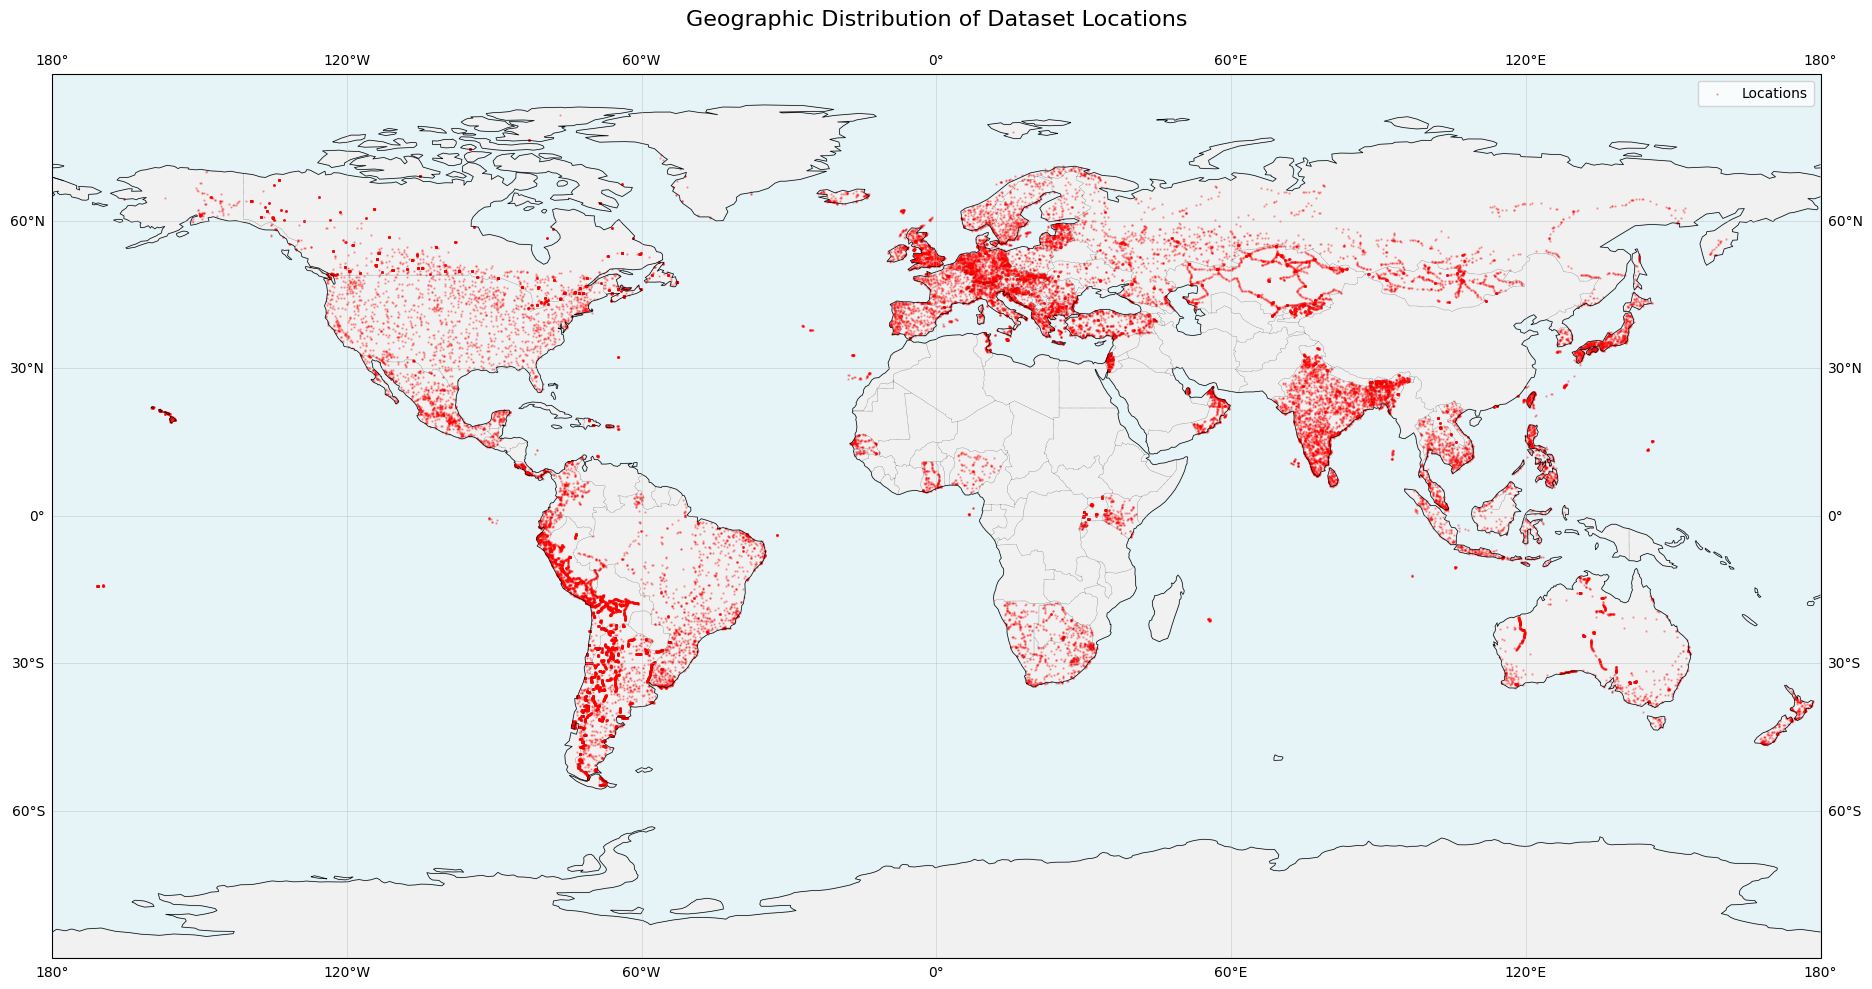

In [4]:
if HAS_CARTOPY:
    # Create figure with map projection
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.3, color='lightblue')
    
    # Plot locations (sample if too many for performance)
    if len(lats) > 50000:
        print(f"Sampling {50000} locations for visualization...")
        indices = np.random.choice(len(lats), 50000, replace=False)
        ax.scatter(lngs[indices], lats[indices], 
                  s=0.5, alpha=0.3, c='red', 
                  transform=ccrs.PlateCarree(),
                  label='Locations')
    else:
        ax.scatter(lngs, lats, 
                  s=0.5, alpha=0.3, c='red', 
                  transform=ccrs.PlateCarree(),
                  label='Locations')
    
    # Set global extent
    ax.set_global()
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    
    plt.title('Geographic Distribution of Dataset Locations', fontsize=16, pad=20)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: Simple scatter plot
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Sample if too many for performance
    if len(lats) > 50000:
        print(f"Sampling {50000} locations for visualization...")
        indices = np.random.choice(len(lats), 50000, replace=False)
        ax.scatter(lngs[indices], lats[indices], s=0.5, alpha=0.3, c='red')
    else:
        ax.scatter(lngs, lats, s=0.5, alpha=0.3, c='red')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Geographic Distribution of Dataset Locations', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()


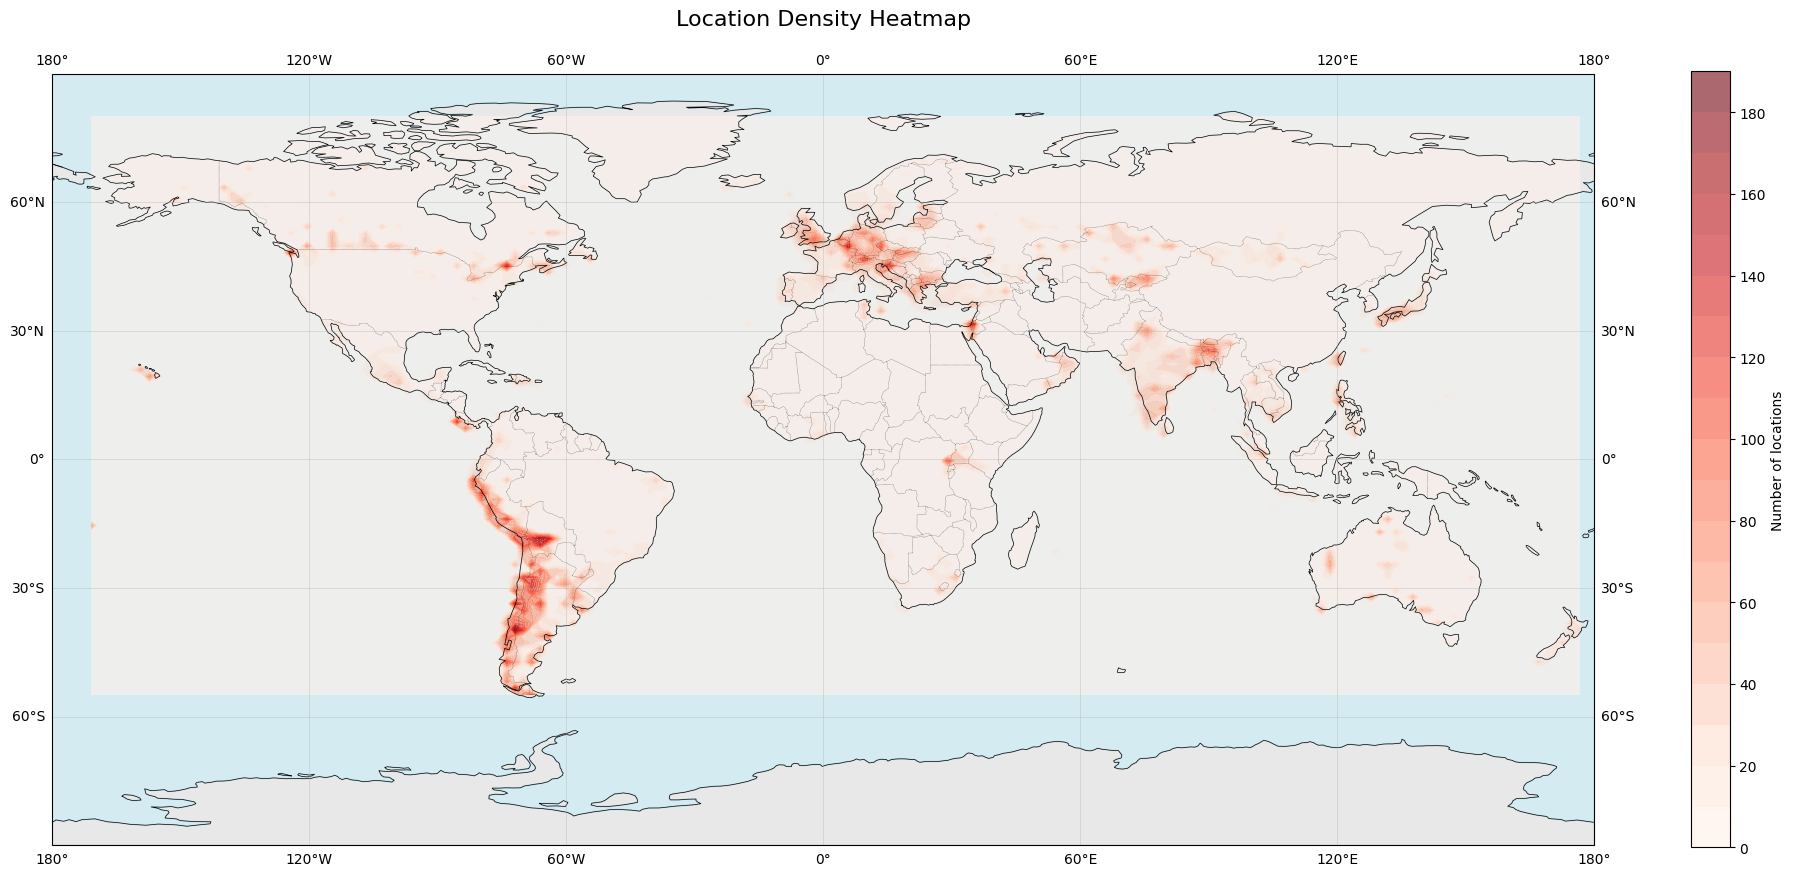

In [5]:
# Alternative: Density heatmap
if HAS_CARTOPY:
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.5, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.5, color='lightblue')
    
    # Create 2D histogram for density
    hist, xedges, yedges = np.histogram2d(lngs, lats, bins=[180, 90])
    
    # Plot heatmap
    im = ax.contourf(xedges[:-1], yedges[:-1], hist.T, 
                     levels=20, cmap='Reds', alpha=0.6,
                     transform=ccrs.PlateCarree())
    
    plt.colorbar(im, ax=ax, label='Number of locations', shrink=0.8)
    ax.set_global()
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    
    plt.title('Location Density Heatmap', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: Simple 2D histogram
    fig, ax = plt.subplots(figsize=(20, 10))
    
    hist, xedges, yedges = np.histogram2d(lngs, lats, bins=[180, 90])
    im = ax.contourf(xedges[:-1], yedges[:-1], hist.T, levels=20, cmap='Reds')
    plt.colorbar(im, ax=ax, label='Number of locations')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Location Density Heatmap', fontsize=16)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()


In [6]:
# Statistics
print("Geographic Coverage Statistics:")
print(f"  Latitude range: {lats.min():.2f}° to {lats.max():.2f}°")
print(f"  Longitude range: {lngs.min():.2f}° to {lngs.max():.2f}°")
print(f"  Total locations: {len(lats):,}")
print(f"  Unique grid cells (1°x1°): {len(set(zip(np.floor(lats), np.floor(lngs)))):,}")


Geographic Coverage Statistics:
  Latitude range: -54.88° to 81.66°
  Longitude range: -170.83° to 178.41°
  Total locations: 42,536
  Unique grid cells (1°x1°): 5,359
